# This is a notebook specified on correlations.

In [1]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [2]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]
def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)
run_db['s100ns_mw5']["phy_bg_path"]

'/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs/s100ns_mw5/phy/p00/r038'

In [3]:
import pickle
with open("/mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations_simu.pkl","rb") as f:
    sf_correlations= pickle.load(f)

In [4]:
for run1 in runs:
    for run2 in runs:
        print(sf_correlations[(run1,run2)])

(89.90369681811877, 1.5485413721722074)
(89.22490319551125, 1.5647262580120558)
(88.77242090600068, 1.5774231376950831)
(88.19266761709777, 1.5999491523758236)
(88.21124043303566, 1.6072969830406458)
(88.03191630425911, 1.5870243423183883)
(88.39210517719535, 1.603390316383907)
(87.87134681180608, 1.6171132396501975)
(87.75803502979113, 1.6203909386068027)
(88.2042600009494, 1.5925746983046773)
(87.86407552743023, 1.6164914800256058)
(87.76659985302264, 1.6210270722084141)
(87.58496956082143, 1.62399508099344)
(87.38096838456619, 1.6096911514844436)
(87.65831319860281, 1.6205320153002856)
(87.51446318967731, 1.6253316875504409)
(87.40657379882632, 1.626478491555422)
(87.01280314496448, 1.6205534519958653)
(87.13228547073355, 1.6307550329555776)
(87.09133245482302, 1.633633579482363)
(86.84807302127139, 1.6370837139707384)
(86.5180641424287, 1.6290435802213732)
(86.5592839271823, 1.6378240096690644)
(86.70447970098833, 1.634501671543831)
(86.47669053137696, 1.6362844640202823)
(84.44916

## Uncertainty of the Cut-Correlation Coefficient

For two cuts (X) and (Y), the correlation between their binary pass/fail decisions is calculated as

$$
\rho_{XY}
=

\frac{p_{XY}-p_Xp_Y}
{\sqrt{p_X(1-p_X)\cdot p_Y(1-p_Y)}},
$$

where:

* (p_X) is the survival probability of cut (X),
* (p_Y) is the survival probability of cut (Y),
* (p_{XY}) is the probability that an event passes both cuts.

The quantities (p_X), (p_Y), and (p_{XY}) are obtained from fitted survival fractions and therefore have statistical uncertainties:

$$
p_X\pm\sigma_X,
\qquad
p_Y\pm\sigma_Y,
\qquad
p_{XY}\pm\sigma_{XY}.
$$

Because (\rho_{XY}) depends nonlinearly on these three quantities through products, square roots, and a division, its uncertainty cannot be obtained by simply adding the survival-fraction uncertainties in quadrature. Instead, Monte Carlo uncertainty propagation is used.
### Monte Carlo uncertainty propagation

The procedure is as follows.

#### 1. Sample possible survival probabilities

Random values of $p_X$, $p_Y$, and $p_{XY}$ are drawn from Gaussian distributions centred on their measured values:

$$
p_X^{(k)} \sim \mathcal{N}\left(p_X,\sigma_X\right),
$$

$$
p_Y^{(k)} \sim \mathcal{N}\left(p_Y,\sigma_Y\right),
$$

$$
p_{XY}^{(k)} \sim
\mathcal{N}\left(p_{XY},\sigma_{XY}\right).
$$

Here, the index $k$ labels one Monte Carlo sample.

#### 2. Recalculate the correlation

For every random draw $k$, a new correlation coefficient is calculated:

$$
\rho_{XY}^{(k)}
=
\frac{
p_{XY}^{(k)}-p_X^{(k)}p_Y^{(k)}
}{
\sqrt{
p_X^{(k)}\left(1-p_X^{(k)}\right)
p_Y^{(k)}\left(1-p_Y^{(k)}\right)
}
}.
$$

#### 3. Repeat the sampling

This procedure is repeated many times, for example

$$
N_{\mathrm{MC}} = 50\,000.
$$

The result is a distribution of possible correlation coefficients:

$$
\rho_{XY}^{(1)},\,
\rho_{XY}^{(2)},\,
\ldots,\,
\rho_{XY}^{(N_{\mathrm{MC}})}.
$$

#### 4. Determine the uncertainty

The standard deviation of the Monte Carlo distribution is used as the uncertainty of the correlation coefficient:

$$
\sigma_{\rho}
=
\operatorname{std}
\left(
\rho_{XY}^{(1)},
\rho_{XY}^{(2)},
\ldots,
\rho_{XY}^{(N_{\mathrm{MC}})}
\right).
$$

The final result is reported as

$$
\rho_{XY} \pm \sigma_{\rho}.
$$
### Physical probability constraints

Not every randomly generated combination of probabilities is physically possible. The individual probabilities must satisfy

$$
0<p_X<1,
\qquad
0<p_Y<1.
$$

In addition, the joint probability must satisfy the Fréchet bounds:

$$
\max(0,p_X+p_Y-1)
\leq p_{XY}
\leq
\min(p_X,p_Y).
$$

The upper bound follows from the fact that the fraction passing both cuts cannot be larger than the fraction passing either individual cut. Monte Carlo samples that violate these conditions are discarded.

### Special case: correlation of a cut with itself

For (X=Y), the two cut decisions are identical. Therefore,

$$
\rho_{XX}=1
$$

exactly, and the corresponding uncertainty is set to

$$
\sigma_{\rho_{XX}}=0.
$$

This case must be treated separately. Independently sampling (p_X), (p_Y), and (p_{XY}) would incorrectly treat identical quantities as independent measurements.

### Limitation of the method

The present calculation assumes that the fitted quantities (p_X), (p_Y), and (p_{XY}) can be sampled independently. In reality, they are statistically related because they are calculated from overlapping sets of events. For example, events contributing to (p_{XY}) also contribute to both (p_X) and (p_Y).

Consequently, the resulting value of (\sigma_\rho) should be interpreted as an approximate propagated uncertainty based on the available survival-fraction uncertainties.

A more rigorous uncertainty could be obtained using an event-level bootstrap. In that approach, the original events or the four pass/fail populations are resampled, and all three survival fractions and the correlation coefficient are recalculated together. This would automatically preserve the statistical dependence between the survival fractions.


### Correlation Between Two Binary Cuts

For each event, the pass/fail decisions of cuts \(X\) and \(Y\) can be represented by binary indicator variables:

$$
X =
\begin{cases}
1, & \text{if the event passes cut } X,\\
0, & \text{if the event fails cut } X,
\end{cases}
$$

and

$$
Y =
\begin{cases}
1, & \text{if the event passes cut } Y,\\
0, & \text{if the event fails cut } Y.
\end{cases}
$$

The Pearson correlation coefficient between \(X\) and \(Y\) is defined as

$$
\rho_{XY}
=
\frac{\operatorname{Cov}(X,Y)}
{\sqrt{\operatorname{Var}(X)\operatorname{Var}(Y)}}.
$$

The covariance can be written as

$$
\operatorname{Cov}(X,Y)
=
\mathbb{E}[XY]
-
\mathbb{E}[X]\mathbb{E}[Y].
$$

Since \(X\) and \(Y\) are binary variables,

$$
\mathbb{E}[X] = P(X=1) = p_X
$$

and

$$
\mathbb{E}[Y] = P(Y=1) = p_Y,
$$

where \(p_X\) and \(p_Y\) are the survival probabilities of cuts \(X\) and \(Y\), respectively.

The product \(XY\) is equal to one only when the event passes both cuts. Therefore,

$$
\mathbb{E}[XY]
=
P(X=1,Y=1)
=
p_{XY},
$$

where \(p_{XY}\) is the probability that an event passes both cuts. The covariance is consequently

$$
\operatorname{Cov}(X,Y)
=
p_{XY}-p_Xp_Y.
$$

For a binary variable, \(X^2=X\). Its variance is therefore

$$
\begin{aligned}
\operatorname{Var}(X)
&=
\mathbb{E}[X^2]-\mathbb{E}[X]^2\\
&=
p_X-p_X^2\\
&=
p_X(1-p_X).
\end{aligned}
$$

Similarly,

$$
\operatorname{Var}(Y)
=
p_Y(1-p_Y).
$$

Substituting the covariance and variances into the Pearson correlation coefficient gives

$$
\boxed{
\rho_{XY}
=
\frac{p_{XY}-p_Xp_Y}
{\sqrt{p_X(1-p_X)\,p_Y(1-p_Y)}}
}.
$$

Thus, the correlation between the two cuts is the standard Pearson correlation applied to their binary pass/fail decisions. For two binary variables, this quantity is also known as the **phi coefficient**.

If the two cuts are statistically independent, then

$$
p_{XY}=p_Xp_Y,
$$

and consequently

$$
\rho_{XY}=0.
$$

A positive value of \(\rho_{XY}\) means that events passing one cut are more likely to pass the other cut. A negative value means that passing one cut is associated with failing the other.

# code

In [5]:
import numpy as np

rng = np.random.default_rng(42)

# def correlation_with_uncertainty(
#     sf_x,
#     err_x,
#     sf_y,
#     err_y,
#     sf_both,
#     err_both,
#     n_samples=50_000,
# ):
#     # Convert percent to probability
#     px_mean = sf_x / 100
#     py_mean = sf_y / 100
#     pxy_mean = sf_both / 100

#     px_err = err_x / 100
#     py_err = err_y / 100
#     pxy_err = err_both / 100

#     # Central correlation value
#     denominator = np.sqrt(
#         px_mean * (1 - px_mean) *
#         py_mean * (1 - py_mean)
#     )

#     if denominator == 0:
#         return np.nan, np.nan

#     rho = (
#         pxy_mean - px_mean * py_mean
#     ) / denominator

#     # Sample the fitted survival fractions
#     px = rng.normal(px_mean, px_err, n_samples)
#     py = rng.normal(py_mean, py_err, n_samples)
#     pxy = rng.normal(pxy_mean, pxy_err, n_samples)

#     # Physically allowed probability conditions
#     valid = (
#         (px > 0) & (px < 1) &
#         (py > 0) & (py < 1) &
#         (pxy >= np.maximum(0, px + py - 1)) &
#         (pxy <= np.minimum(px, py))
#     )

#     px = px[valid]
#     py = py[valid]
#     pxy = pxy[valid]

#     if len(px) < 100:
#         return rho, np.nan

#     denominator_samples = np.sqrt(
#         px * (1 - px) *
#         py * (1 - py)
#     )

#     rho_samples = (
#         pxy - px * py
#     ) / denominator_samples

#     rho_error = np.std(rho_samples, ddof=1)

#     return rho, rho_error
import numpy as np


def correlation_with_uncertainty(
    sf_x,
    err_x,
    sf_y,
    err_y,
    sf_both,
    err_both,
):
    # Convert percentages to probabilities
    px = sf_x / 100.0
    py = sf_y / 100.0
    pxy = sf_both / 100.0

    sigma_px = err_x / 100.0
    sigma_py = err_y / 100.0
    sigma_pxy = err_both / 100.0

    # Check the central probabilities
    lower_bound = max(0.0, px + py - 1.0)
    upper_bound = min(px, py)

    if not (
        0.0 < px < 1.0
        and 0.0 < py < 1.0
        and lower_bound <= pxy <= upper_bound
    ):
        return np.nan, np.nan

    denominator = np.sqrt(
        px * (1.0 - px) *
        py * (1.0 - py)
    )

    rho = (pxy - px * py) / denominator

    # Partial derivatives
    drho_dpxy = 1.0 / denominator

    drho_dpx = (
        -py / denominator
        - rho * (1.0 - 2.0 * px)
        / (2.0 * px * (1.0 - px))
    )

    drho_dpy = (
        -px / denominator
        - rho * (1.0 - 2.0 * py)
        / (2.0 * py * (1.0 - py))
    )

    # Gaussian error propagation
    rho_variance = (
        (drho_dpx * sigma_px) ** 2
        + (drho_dpy * sigma_py) ** 2
        + (drho_dpxy * sigma_pxy) ** 2
    )

    rho_error = np.sqrt(rho_variance)

    return rho, rho_error

In [6]:
cut_correlations = {}

for run1 in runs:
    for run2 in runs:

        # Individual survival fractions
        sf_1, sf_err_1 = sf_correlations[(run1, run1)]
        sf_2, sf_err_2 = sf_correlations[(run2, run2)]

        # Survival fraction after applying both cuts
        sf_both, sf_both_err = sf_correlations[(run1, run2)]

        # A cut is perfectly correlated with itself
        if run1 == run2:
            correlation = 1.0
            correlation_err = 0.0

        else:
            correlation, correlation_err = (
                correlation_with_uncertainty(
                    sf_x=sf_1,
                    err_x=sf_err_1,
                    sf_y=sf_2,
                    err_y=sf_err_2,
                    sf_both=sf_both,
                    err_both=sf_both_err,
                )
            )

        cut_correlations[(run1, run2)] = (
            float(correlation),
            float(correlation_err),
        )

In [7]:
for run1 in runs:
    for run2 in runs:
        print(
            run1,
            run2,
            cut_correlations[(run1, run2)]
        )

s20ns_mw5 s20ns_mw5 (1.0, 0.0)
s20ns_mw5 s20ns_mw7 (0.9168177537832775, 0.21657470544362356)
s20ns_mw5 s30ns_mw3 (0.877447765884135, 0.2184752880195645)
s20ns_mw5 s30ns_mw5 (0.8126399431071816, 0.22492119436197075)
s20ns_mw5 s30ns_mw7 (0.7969412297493113, 0.22948798890947286)
s20ns_mw5 s40ns_mw1 (0.7851815136094143, 0.2261781787408982)
s20ns_mw5 s40ns_mw3 (0.8244366313271404, 0.22622566125791727)
s20ns_mw5 s40ns_mw5 (0.7693455745465401, 0.2306809449535265)
s20ns_mw5 s40ns_mw7 (0.7540960686198035, 0.23241110125442277)
s20ns_mw5 s50ns_mw1 (0.802235034821931, 0.22618808222351103)
s20ns_mw5 s50ns_mw3 (0.7603397523394719, 0.23243107780180888)
s20ns_mw5 s50ns_mw5 (0.7459767260083308, 0.23439935546237467)
s20ns_mw5 s50ns_mw7 (0.7392163847060759, 0.23304766201061752)
s20ns_mw5 s60ns_mw1 (0.7098910511465546, 0.23393838083144317)
s20ns_mw5 s60ns_mw3 (0.746254330420922, 0.2323831153400986)
s20ns_mw5 s60ns_mw5 (0.7362050514409988, 0.23265210502697992)
s20ns_mw5 s60ns_mw7 (0.7183410957754883, 0.234

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
## plots eveything together
# correlation_matrix = np.array([
#     [cut_correlations[(run1, run2)] for run2 in runs]
#     for run1 in runs
# ])

# fig, ax = plt.subplots(figsize=(120, 100))

# sns.heatmap(
#     correlation_matrix,
#     mask=np.isnan(correlation_matrix),
#     annot=True,
#     fmt=".3f",
#     cmap="viridis",
#     # vmin=-1,
#     # vmax=1,
#     # center=0,
#     square=True,
#     linewidths=0.5,
#     xticklabels=runs,
#     yticklabels=runs,
#     cbar_kws={"label": r"Cut correlation $\rho$"},
#     ax=ax,
# )

# ax.set_xlabel("Second cut")
# ax.set_ylabel("First cut")
# ax.set_title("Correlation between A/E cuts")

# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [9]:

# Runs displayed on the x-axis
x_runs = [
    "s30ns_mw3",
    "s30ns_mw5",
    "s30ns_mw7",
    "s40ns_mw1",
    "s40ns_mw3",
    "s40ns_mw5",
    "s40ns_mw7",
    "s50ns_mw1",
    "s50ns_mw3",
    "s50ns_mw5",
    "s50ns_mw7",
    "s60ns_mw1",
    "s60ns_mw3",
    "s60ns_mw5",
    "s60ns_mw7",
]

# Runs displayed on the y-axis
y_runs = [
    "s200ns_mw3",
    "s200ns_mw5",
    "s200ns_mw7",
    "s300ns_mw3",
    "s300ns_mw5",
    "s300ns_mw7",
    "s500ns_mw3",
    "s500ns_mw5",
    "s500ns_mw7",
]


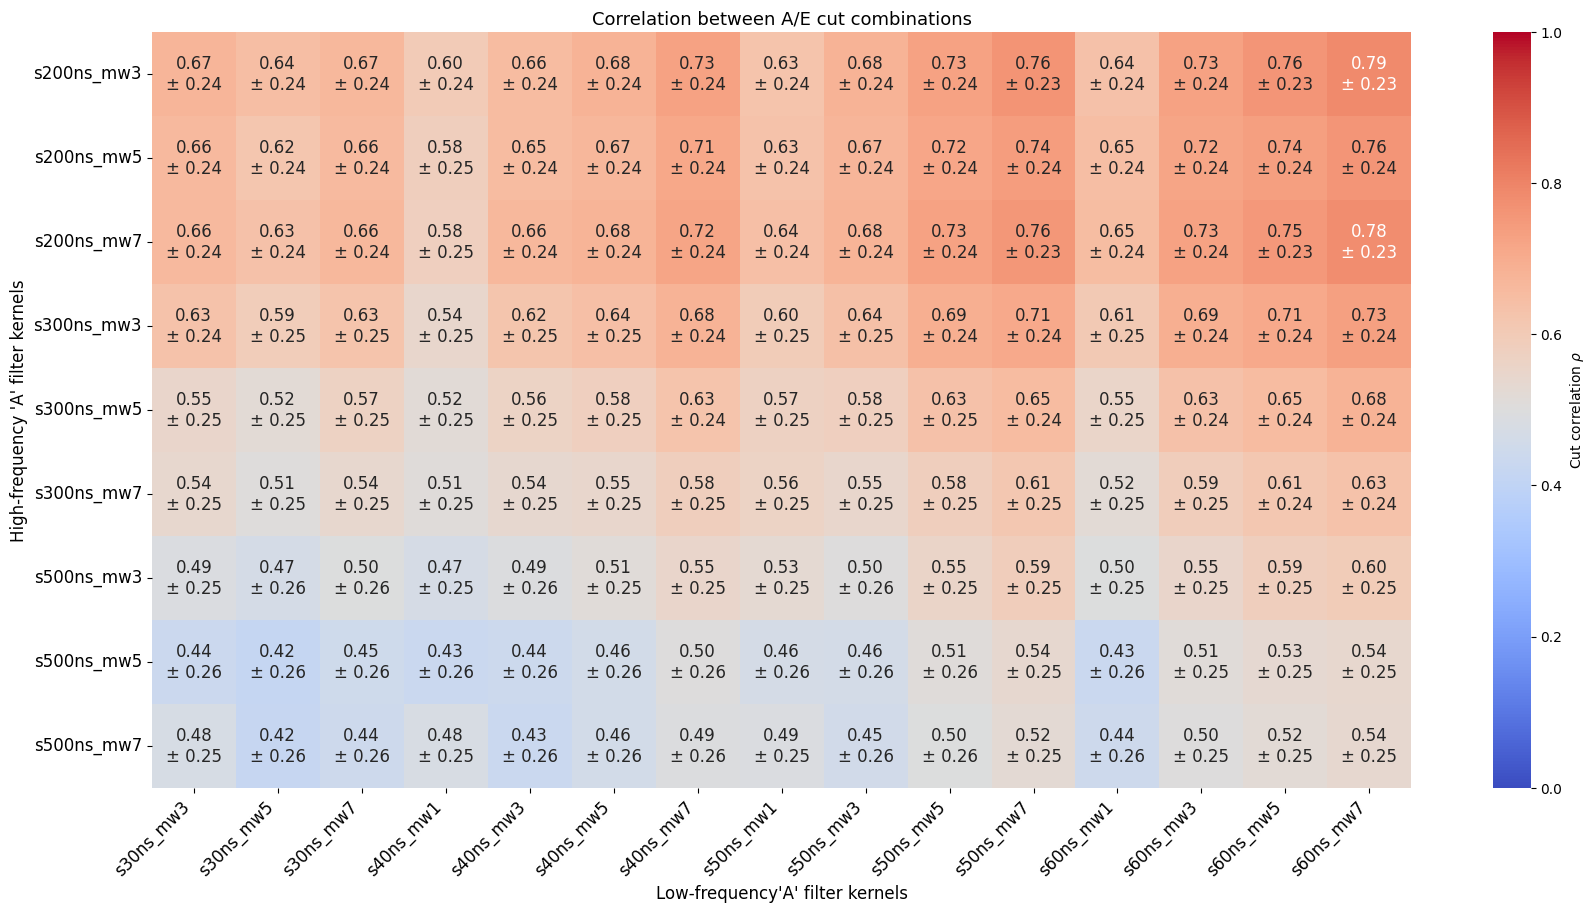

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_x = len(x_runs)
n_y = len(y_runs)

correlation_values = np.full(
    (n_y, n_x),
    np.nan,
    dtype=float,
)

correlation_errors = np.full(
    (n_y, n_x),
    np.nan,
    dtype=float,
)

annotations = np.full(
    (n_y, n_x),
    "",
    dtype=object,
)


# Build the selected correlation matrix
for i, y_run in enumerate(y_runs):
    for j, x_run in enumerate(x_runs):

        # Change the order if your dictionary uses (x_run, y_run)
        result = cut_correlations.get((y_run, x_run))

        if result is None:
            continue

        correlation, correlation_err = result

        correlation_values[i, j] = correlation
        correlation_errors[i, j] = correlation_err

        annotations[i, j] = (
            f"{correlation:.2f}\n"
            f"± {correlation_err:.2f}"
        )


# Mask missing values
missing_mask = np.isnan(correlation_values)

fig_width = max(10, 1.2 * n_x)
fig_height = max(7, 1.0 * n_y)

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

sns.heatmap(
    correlation_values,
    mask=missing_mask,
    annot=annotations,
    fmt="",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    # center=0,
    square=True,
    # linewidths=0.5,
    linecolor="white",
    xticklabels=x_runs,
    yticklabels=y_runs,
    ax=ax,
    annot_kws={"fontsize": 12},
    cbar_kws={
        "label": r"Cut correlation $\rho$"
    },
)

ax.set_xlabel("Low-frequency'A' filter kernels",fontsize=12)
ax.set_ylabel("High-frequency 'A' filter kernels",fontsize=12)
ax.set_title("Correlation between A/E cut combinations",fontsize=13)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=12,
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=12,
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

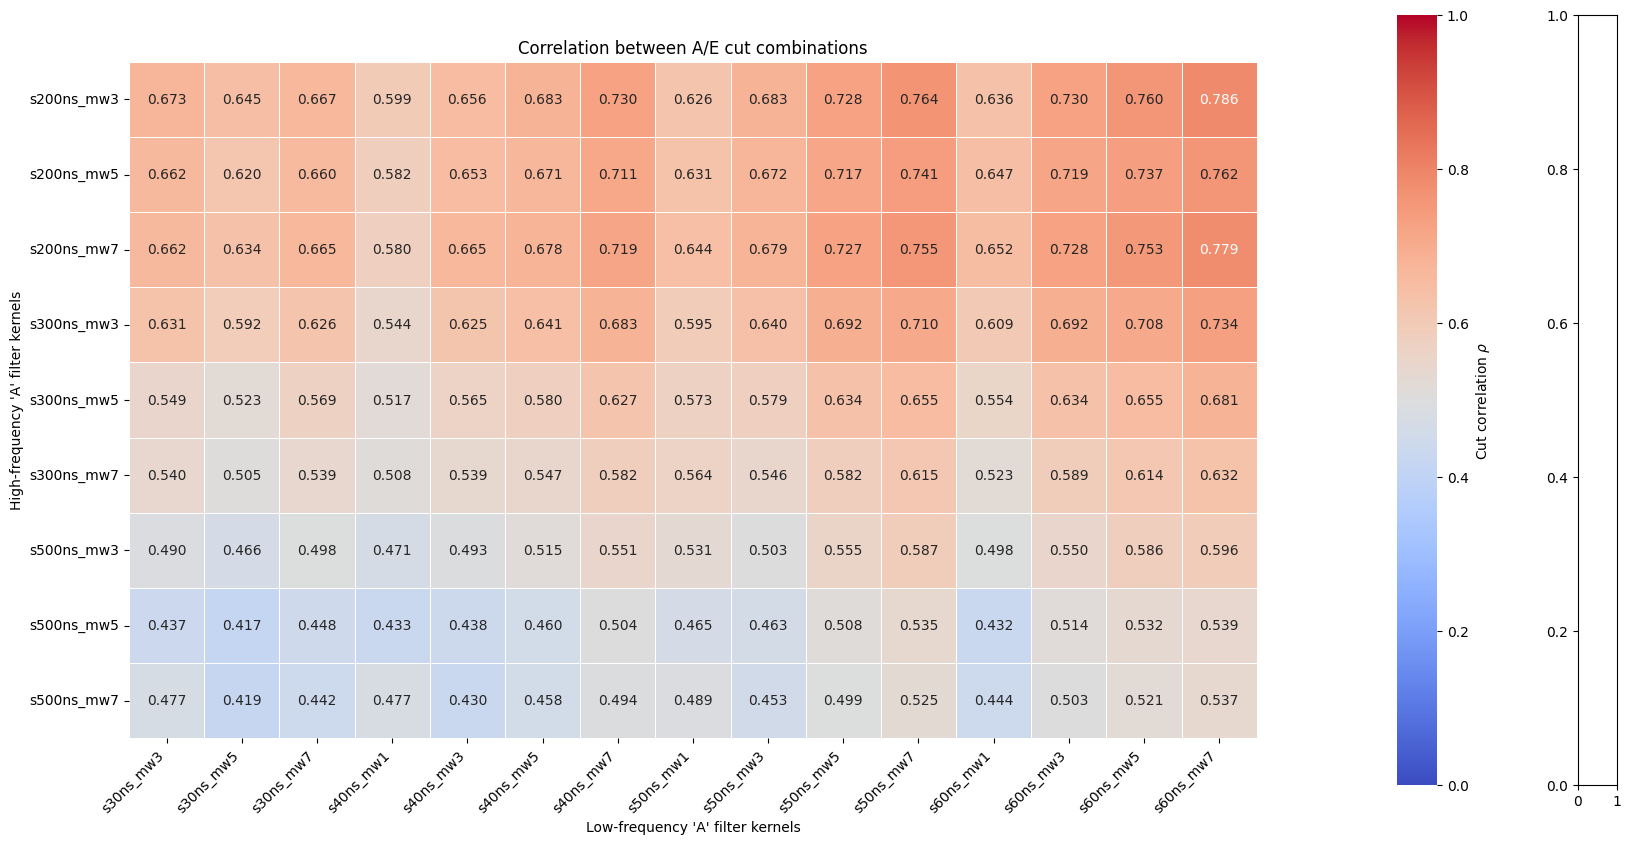

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_x = len(x_runs)
n_y = len(y_runs)
# shape = (n_y + 1, n_x + 1)
shape = (n_y, n_x)
# Main matrix: binary cut correlations
rho_values = np.full(shape, np.nan)
rho_annotations = np.full(shape, "", dtype=object)

# Margins: individual survival fractions
own_sf_values = np.full(shape, np.nan)
own_sf_annotations = np.full(shape, "", dtype=object)


# ------------------------------------------------------------
# Main correlation matrix
# ------------------------------------------------------------
for i, y_run in enumerate(y_runs):
    for j, x_run in enumerate(x_runs):

        # Joint survival fraction
        joint_result = sf_correlations.get((y_run, x_run))

        # Individual survival fractions
        y_result = sf_correlations.get((y_run, y_run))
        x_result = sf_correlations.get((x_run, x_run))

        if joint_result is None or y_result is None or x_result is None:
            continue

        sf_both, sf_both_err = joint_result
        sf_y, sf_y_err = y_result
        sf_x, sf_x_err = x_result

        # Convert percentages to probabilities
        p_both = sf_both / 100
        p_y = sf_y / 100
        p_x = sf_x / 100

        denominator = np.sqrt(
            p_y * (1 - p_y) *
            p_x * (1 - p_x)
        )

        if denominator == 0:
            continue

        rho = (p_both - p_y * p_x) / denominator

        rho_values[i, j] = rho
        rho_annotations[i, j] = f"{rho:.3f}"


# ------------------------------------------------------------
# Bottom row: individual SF of x-axis cuts
# ------------------------------------------------------------
# for j, x_run in enumerate(x_runs):

#     result = sf_correlations.get((x_run, x_run))

#     if result is None:
#         continue

#     value, error = result

#     own_sf_values[n_y, j] = value
#     own_sf_annotations[n_y, j] = (
#         f"{value:.2f}\n± {error:.3f}"
#     )


# ------------------------------------------------------------
# Right column: individual SF of y-axis cuts
# # ------------------------------------------------------------
# for i, y_run in enumerate(y_runs):

#     result = sf_correlations.get((y_run, y_run))

#     if result is None:
#         continue

#     value, error = result

#     own_sf_values[i, n_x] = value
#     own_sf_annotations[i, n_x] = (
#         f"{value:.2f}\n± {error:.3f}"
#     )


# x_labels = list(x_runs) + ["Own SF"]
# y_labels = list(y_runs) + ["Own SF"]

x_labels = list(x_runs)
y_labels = list(y_runs)


# ------------------------------------------------------------
# Plot with two independent color bars
# ------------------------------------------------------------
fig_width = max(13, 1.2 * (n_x + 1))
fig_height = max(8, 1.0 * (n_y + 1))

fig, (ax, rho_cbar_ax, sf_cbar_ax) = plt.subplots(
    1,
    3,
    figsize=(fig_width, fig_height),
    gridspec_kw={
        "width_ratios": [20, 0.7, 0.7],
        "wspace": 0.35,
    },
)

# Correlation layer
sns.heatmap(
    rho_values,
    mask=np.isnan(rho_values),
    annot=rho_annotations,
    fmt="",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    # center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=x_labels,
    yticklabels=y_labels,
    ax=ax,
    cbar=True,
    cbar_ax=rho_cbar_ax,
    cbar_kws={
        "label": r"Cut correlation $\rho$"
    },
    annot_kws={"fontsize": 10},
)

# # Own-SF margin layer
# sns.heatmap(
#         own_sf_values,
#         mask=np.isnan(own_sf_values),
#         annot=own_sf_annotations,
#         fmt="",
#         cmap="viridis",
#         vmin=0,
#         vmax=100,
#         square=True,
#         linewidths=0.5,
#         linecolor="white",
#         xticklabels=x_labels,
#         yticklabels=y_labels,
#         ax=ax,
#         cbar=True,
#         cbar_ax=sf_cbar_ax,
#         cbar_kws={
#             "label": "Individual survival fraction (%)"
#         },
#         annot_kws={"fontsize": 9},
# )

# Separate the SF margins visually
# ax.axhline(n_y, color="black", linewidth=3)
# ax.axvline(n_x, color="black", linewidth=3)

ax.set_xlabel("Low-frequency 'A' filter kernels")
ax.set_ylabel("High-frequency 'A' filter kernels")
ax.set_title("Correlation between A/E cut combinations")

ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=10)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.show()